<a href="https://colab.research.google.com/github/juanjomar22-glitch/Juan.Marquez/blob/main/Taller_Integracion_Multidimensional_Clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integracion Multidimensional

## Caso de estudio
Una entidad del sector Fintech requiere reducir el numero de sucursales en las cuales atiende a cada uno de sus solicitantes de credito. Para ello, se plantea una integracion multidimensional de los datos hacia cinco nuevas sucursales.


## Objetivo
Realizar la integracion multidimensional de los solicitantes de credito tomando como referencia las variables numericas:

- Edad
- Hijos
- Perscargo
- Estrato
- Ingresos
- Egresos
- Monto (EAD)
- Plazo
- Cuota (COP)

Ademas, identificar para cada nueva sucursal:
- Numero de clientes.
- Municipios de procedencia.
- Porcentaje de preaprobacion y prenegacion.


In [27]:
# 0. Cargar las librerias de trabajo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# 1. Cargar la base de datos
nxl = '/content/drive/MyDrive/Linea de enfasis/Integracion de datos y prospectiva/Taller/4. SolicitantesCrédito(USD)_Municipios.xlsx'
XDB = pd.read_excel(nxl, sheet_name='Base Datos Municipios')
XDB.head()


,Cédula,Edad,Sexo,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,...,ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD,Net_Income,Municipio
0,1,38,NR,Casado,1,0,0,3,Bachiller,Ninguno,...,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1,0.041659,582.478943,0.063702,-329.478667,Bello
1,2,51,NR,Separado,6,1,1,4,Técnico,Ninguno,...,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1,0.234951,479.839966,0.465636,-78.446000,Itagüí
2,3,37,Mujer,Casado,2,0,0,3,Tecnólogo,Indefinido,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,0,0.170330,417.653107,0.290071,-111.745639,Sabaneta
3,4,29,NR,Separado,1,0,0,2,Tecnólogo,Ninguno,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.201659,316.791107,0.278389,-78.346889,Sabaneta
4,5,42,Mujer,Casado,3,4,4,2,Especializacion,Ninguno,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.140929,441.809570,0.203359,-56.624028,Sabaneta


In [29]:
# 2. Seleccionar las variables para la integracion
VA = ['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)']

XD = XDB[VA].copy()
XD = XD.dropna()
XD.head()


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,38,1,0,3,1356.14400,1685.622667,625.562230,48,18.375890
1,51,6,1,4,286.01600,364.462000,140.031984,36,5.062492
2,37,2,0,3,517.46325,629.208889,284.564492,36,10.287688
3,29,1,0,2,473.27000,551.616889,309.647588,24,15.458878
4,42,3,4,2,750.09175,806.715778,500.663578,24,24.995180


In [30]:
# 3. Normalizar los datos
XDN = (XD - XD.mean()) / XD.std()
XDN.head()


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,-0.248918,-0.060279,-0.828771,0.087742,1.249927,2.043748,0.210203,1.214291,-0.222113
1,0.813780,3.996756,0.149939,1.102768,-0.875482,-0.557537,-0.881898,0.270484,-0.477955
2,-0.330664,0.751128,-0.828771,0.087742,-0.415798,-0.036266,-0.556802,0.270484,-0.377543
3,-0.984633,-0.060279,-0.828771,-0.927284,-0.503572,-0.189040,-0.500382,-0.673322,-0.278169
4,0.078066,1.562535,3.086069,-0.927284,0.046231,0.313234,-0.070731,-0.673322,-0.094911


In [31]:
# 4. Crear las semillas de integracion
XC = np.array(XDN.iloc[0:5, :])
XD1 = np.array(XDN)

print('Semillas de integracion:')
print(XC)


Semillas de integracion:
[[-0.24891823 -0.06027912 -0.82877061  0.08774188  1.24992707  2.04374766
   0.21020311  1.21429071 -0.22211326]
 [ 0.8137803   3.9967559   0.1499393   1.10276775 -0.87548166 -0.55753657
  -0.88189823  0.27048411 -0.47795478]
 [-0.33066428  0.75112788 -0.82877061  0.08774188 -0.41579833 -0.0362662
  -0.55680181  0.27048411 -0.37754299]
 [-0.98463261 -0.06027912 -0.82877061 -0.92728399 -0.50357168 -0.18904009
  -0.50038249 -0.67332248 -0.27816904]
 [ 0.07806593  1.56253488  3.08606901 -0.92728399  0.04623112  0.31323396
  -0.07073096 -0.67332248 -0.0949114 ]]


In [32]:
# 5. Aplicar K-Medoids
def KMedoids(XD1, XC, n_iter=10):
    nc = np.zeros(len(XD1), dtype=int)

    for it in range(n_iter):
        for i in range(len(XD1)):
            distancias = []
            for j in range(len(XC)):
                d = np.linalg.norm(XD1[i,:] - XC[j,:])
                distancias.append(d)
            nc[i] = np.argmin(distancias)

        XC_new = XC.copy()

        for j in range(len(XC)):
            idx = np.where(nc == j)[0]
            if len(idx) > 0:
                suma_distancias = []
                for a in idx:
                    suma = 0
                    for b in idx:
                        suma = suma + np.linalg.norm(XD1[a,:] - XD1[b,:])
                    suma_distancias.append(suma)
                mejor = idx[np.argmin(suma_distancias)]
                XC_new[j,:] = XD1[mejor,:]

        if np.allclose(XC, XC_new):
            print('El algoritmo converge en la iteracion', it+1)
            XC = XC_new
            break

        XC = XC_new

    for i in range(len(XD1)):
        distancias = []
        for j in range(len(XC)):
            d = np.linalg.norm(XD1[i,:] - XC[j,:])
            distancias.append(d)
        nc[i] = np.argmin(distancias) + 1

    return nc, XC

nc, XC = KMedoids(XD1, XC)

XDB2 = XDB.loc[XD.index].copy()
XDB2['Cluster'] = nc
XDB2[['Cédula','Municipio','PreApr','Cluster']].head()


El algoritmo converge en la iteracion 3


,Cédula,Municipio,PreApr,Cluster
0,1,Bello,1,1
1,2,Itagüí,1,2
2,3,Sabaneta,0,3
3,4,Sabaneta,1,4
4,5,Sabaneta,1,5


In [33]:
# 6. Numero de clientes por nueva sucursal
clientes_cluster = XDB2.groupby('Cluster').size().reset_index(name='Clientes')
clientes_cluster


,Cluster,Clientes
0,1,1358
1,2,261
2,3,2267
3,4,1407
4,5,549


In [34]:
# 7. Porcentaje de preaprobacion y prenegacion
resumen_aprobacion = XDB2.groupby('Cluster')['PreApr'].agg(['count','sum'])
resumen_aprobacion.columns = ['Clientes','PreAprobados']
resumen_aprobacion['PreNegados'] = resumen_aprobacion['Clientes'] - resumen_aprobacion['PreAprobados']
resumen_aprobacion['% PreAprobacion'] = 100 * resumen_aprobacion['PreAprobados'] / resumen_aprobacion['Clientes']
resumen_aprobacion['% PreNegacion'] = 100 * resumen_aprobacion['PreNegados'] / resumen_aprobacion['Clientes']
resumen_aprobacion = resumen_aprobacion.reset_index()
resumen_aprobacion


,Cluster,Clientes,PreAprobados,PreNegados,% PreAprobacion,% PreNegacion
0,1,1358,1211,147,89.175258,10.824742
1,2,261,121,140,46.360153,53.639847
2,3,2267,924,1343,40.758712,59.241288
3,4,1407,387,1020,27.505330,72.494670
4,5,549,240,309,43.715847,56.284153


In [35]:
# 8. Municipios de procedencia por cluster
municipios_cluster = XDB2.groupby(['Cluster','Municipio']).size().reset_index(name='Clientes')
municipios_cluster = municipios_cluster.sort_values(['Cluster','Clientes'], ascending=[True,False])
municipios_cluster


,Cluster,Municipio,Clientes
0,1,Bello,723
3,1,Medellín,432
2,1,Itagüí,115
1,1,Envigado,49
4,1,Sabaneta,39
10,2,Sabaneta,102
6,2,Caldas,91
5,2,Bello,30
8,2,Itagüí,26
9,2,Medellín,9


In [36]:
# 9. Perfil promedio por cluster
perfil_cluster = XDB2.groupby('Cluster')[VA].mean()
perfil_cluster


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Cluster,,,,,,,,,
1,41.107511,0.905744,0.565538,3.825479,1413.640572,1266.282910,1050.069443,32.401325,60.129034
2,42.065134,4.689655,0.586207,2.819923,635.482896,557.279638,454.219651,34.459770,23.668343
3,44.861932,0.864579,0.657256,2.849140,556.433843,497.210050,397.766743,37.922805,15.066844
4,34.236674,0.915423,0.623312,2.171997,384.750274,337.364977,285.200058,25.289979,25.128428
5,42.092896,1.045537,3.021858,2.868852,651.525463,576.563222,475.453124,28.546448,31.931508


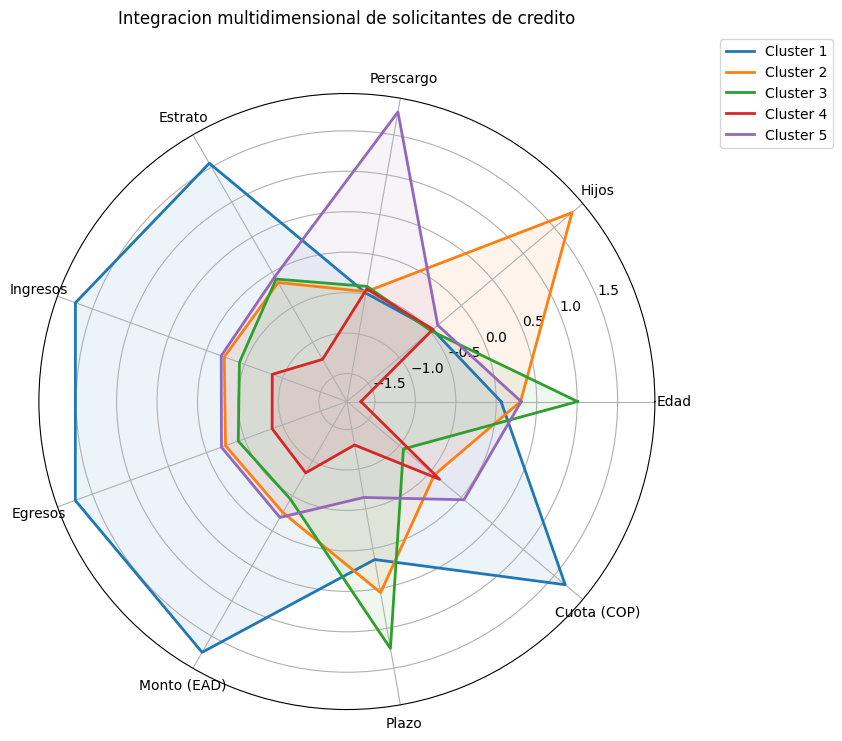

In [40]:
# 10. Grafico de radar para representar los clusters
perfil_norm = (perfil_cluster - perfil_cluster.mean()) / perfil_cluster.std()

variables = list(perfil_norm.columns)
N = len(variables)
angulos = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i in perfil_norm.index:
    valores = perfil_norm.loc[i].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, linewidth=2, label='Cluster ' + str(i))
    ax.fill(angulos, valores, alpha=0.08)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(variables)
plt.title('Integracion multidimensional de solicitantes de credito', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## Analisis de resultados

La integracion multidimensional permite agrupar los solicitantes en cinco nuevas sucursales a partir de su similitud en variables sociodemograficas y financieras. Con ello se puede identificar:

- El tamano de cada nueva sucursal.
- Los municipios que aportan mayor cantidad de clientes a cada grupo.
- El comportamiento de preaprobacion y prenegacion en cada cluster.
- El perfil promedio de riesgo y capacidad de pago de los solicitantes.

En general, los clusters con mayores ingresos, mayor monto y mejor relacion entre ingresos y egresos tenderan a mostrar un mejor comportamiento de preaprobacion. Por otro lado, los grupos con menores ingresos o mayores cargas pueden concentrar una mayor proporcion de prenegaciones.


## Conclusiones

La metodologia de integracion multidimensional permite reducir la operacion a cinco nuevas sucursales, facilitando la toma de decisiones para la entidad financiera. El uso de semillas iniciales y la distancia euclidiana permite construir una segmentacion clara y facil de interpretar, coherente con el enfoque trabajado en clase.
